<a href="https://colab.research.google.com/github/mahdifb1381/FIS4031/blob/main/MP1/MP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# بسم الله الرحمن الرحیم


# سوال اول

## 1 -1

In [1]:
# @title آپلود دیتاست

!pip install --upgrade --no-cache-dir gdown
!gdown 108heL_Qri8_hiK-HnRtR_pcB7oYKg5RV

Downloading...
From: https://drive.google.com/uc?id=108heL_Qri8_hiK-HnRtR_pcB7oYKg5RV
To: /content/BankChurners.csv
100% 1.51M/1.51M [00:00<00:00, 113MB/s]


###درباره این مجموعه داده به صورت خلاصه توضیح دهید


این دیتاست شامل اطلاعات حدود 10,000 مشتری کارت اعتباری است. هر مشتری با ویژگی‌هایی مثل سن، حقوق، وضعیت تاهل، سقف اعتبار کارت، نوع کارت اعتباری و ... مشخص شده است. حدود 18 ویژگی برای هر مشتری وجود دارد.
هدف اصلی از این داده‌ست، پیش‌بینی مشتریانی است که احتمال ترک خدمات کارت اعتباری آن‌ها بالا است. این کار به بانک کمک می‌کند تا به صورت پیش‌گیرانه با این مشتریان ارتباط برقرار کند، خدمات بهتری ارائه دهد و تلاش کند تا تصمیم آن‌ها را تغییر دهد.


یکی از چالش‌های اصلی در این مسئله، عدم تعادل داده‌ها است. تنها 16.07% از مشتریان در این داده‌ست، تصمیم به ترک خدمات داده‌اند. این عدم تعادل می‌تواند باعث شود مدل‌های پیش‌بینی به خوبی آموزش نبینند و کار چالشی بشه. همین دیگه

### ویژگی های موجود در این مجموعه داده را نام ببرید


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/BankChurners.csv")
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

ویژگی ها شامل :
1. پرچم ریزش - Attrition_Flag
2. شماره مشتری - CLIENTNUM
2. سن مشتری - Customer_Age
3. جنسیت - Gender
4. تعداد افراد تحت تکفل - Dependent_count
5. سطح تحصیلات - Education_Level
6. وضعیت تاهل - Marital_Status
7. دسته درآمدی - Income_Category
8. دسته کارت اعتباری - Card_Category
9. تعداد ماه‌هایی که مشتری با بانک بوده است - Months_on_book
10. تعداد کل روابط با بانک - Total_Relationship_Count
11. تعداد ماه‌های غیرفعال در 12 ماه گذشته - Months_Inactive_12_mon
12. تعداد تماس‌های مشتری با بانک در 12 ماه گذشته - Contacts_Count_12_mon
13. سقف اعتبار کارت اعتباری - Credit_Limit
14. مانده حساب جاری - Total_Revolving_Bal
15. متوسط موجودی قابل استفاده - Avg_Open_To_Buy
16. تغییر کل مبلغ هزینه شده در Q4 ماه های نسبت به Q1 - Total_Amt_Chng_Q4_Q1
17. کل مبلغ هزینه شده - Total_Trans_Amt
18. کل تعداد تراکنش‌ها - Total_Trans_Ct
19. تغییر کل تعداد تراکنش‌ها در Q4 نسبت به Q1 - Total_Ct_Chng_Q4_Q1
20. متوسط نسبت استفاده از اعتبار - Avg_Utilization_Ratio

منظور از Q1 ماه های ربع اول سال است


###  چه تعداد نمونه  در این مجموعه داده موجود است؟


In [ ]:
print("تعداد نمونه‌ها:", len(df))

تعداد نمونه‌ها: 10127


## 2.1

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

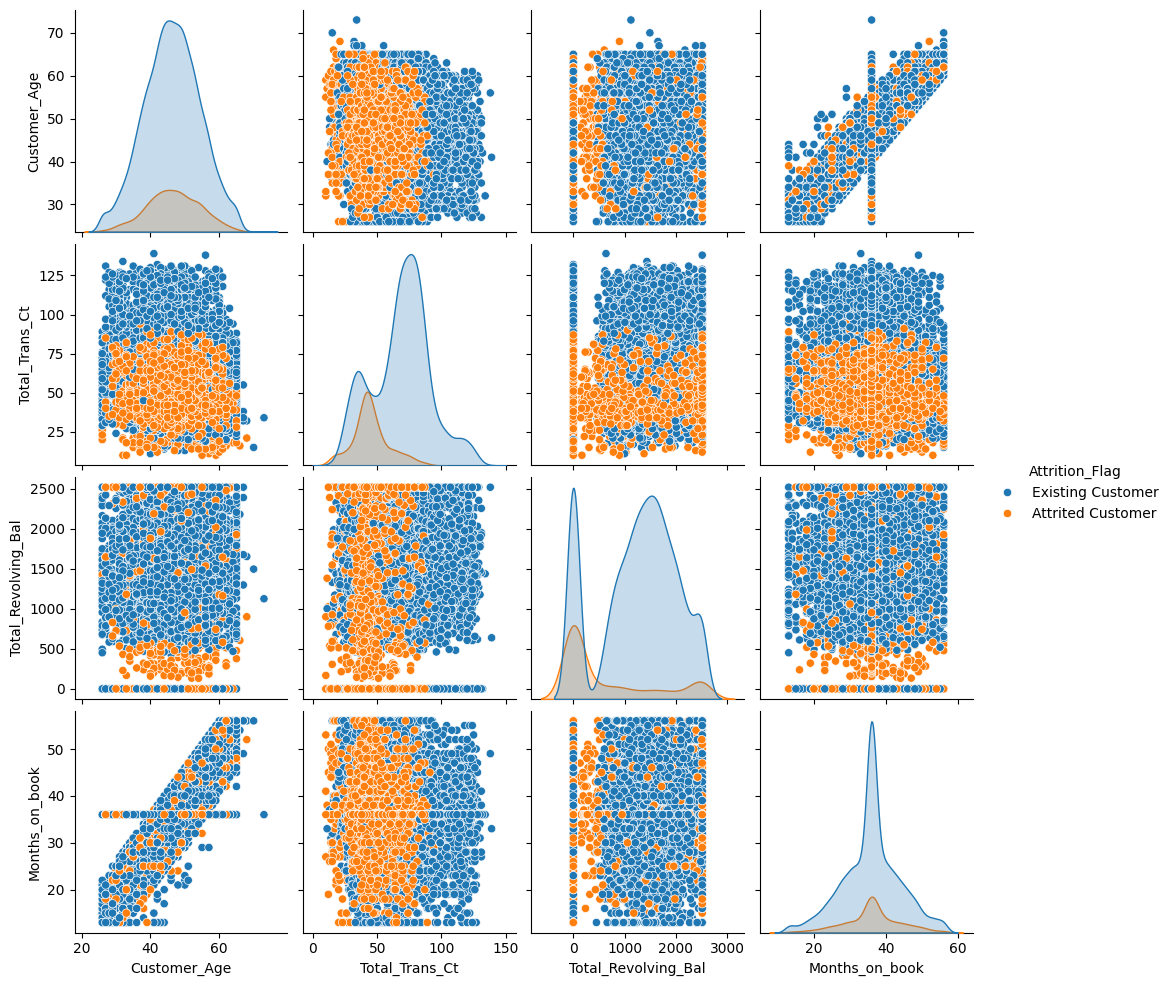

In [5]:
selected_features_1 = ['Customer_Age', 'Total_Trans_Ct', 'Total_Revolving_Bal', 'Months_on_book']
sns.pairplot(
    df,
    vars = selected_features_1,
    diag_kind= 'kde',
    hue='Attrition_Flag' # اضافه کردن این آرگومان برای قسمت امتیازی است.
)
plt.show()

## 3.1

In [6]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

<Axes: >

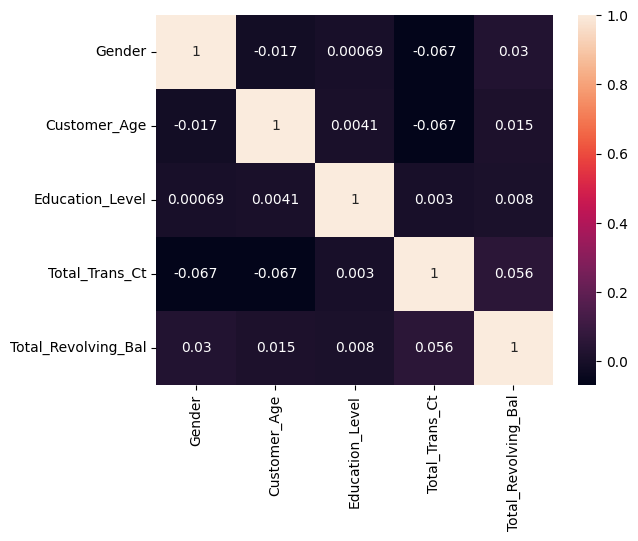

In [7]:
selected_features = [ 'Gender', 'Customer_Age', 'Education_Level', 'Total_Trans_Ct', 'Total_Revolving_Bal']
encoded_df = df[selected_features].copy()
gender_encoder = LabelEncoder()
education_encoder = LabelEncoder()
encoded_df['Gender'] = gender_encoder.fit_transform(encoded_df['Gender'])
encoded_df['Education_Level'] = education_encoder.fit_transform(encoded_df['Education_Level'])
corr_matrix = encoded_df.corr()
sns.heatmap(corr_matrix, annot=True)

<Axes: >

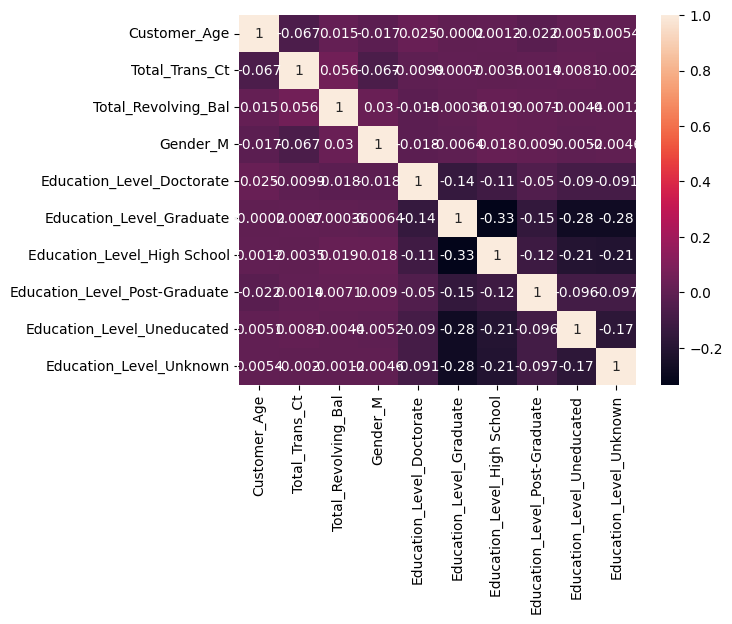

In [ ]:
selected_features = [ 'Gender', 'Customer_Age', 'Education_Level', 'Total_Trans_Ct', 'Total_Revolving_Bal']
encoded_df = pd.get_dummies(df[selected_features], columns=['Gender', 'Education_Level'], drop_first=True)
corr_matrix = encoded_df.corr()
sns.heatmap(corr_matrix, annot=True)

## 4.1

In [8]:
nan_count = df.isna().sum().sum()
# Total number of NaN values
print('before dropna: ',df.shape)
df.dropna(axis=0, inplace=True)
print('after dropna: ',df.shape)
print(f"There are {nan_count} NaN values in the DataFrame.")

before dropna:  (10127, 23)
after dropna:  (10127, 23)
There are 0 NaN values in the DataFrame.


## 5.1

### دارای چند کلاس است و نام آن‌ها چیست؟ Atrrition Flag

In [ ]:
print(f"The 'Attrition_Flag' feature has {df['Attrition_Flag'].nunique()} classes.")
print(f"The unique classes are: {df['Attrition_Flag'].unique()}")

The 'Attrition_Flag' feature has 2 classes.
The unique classes are: ['Existing Customer' 'Attrited Customer']


###  پخش داده موجود در این ویژگی را به صورت یک  pie plot نمایش دهید.


Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


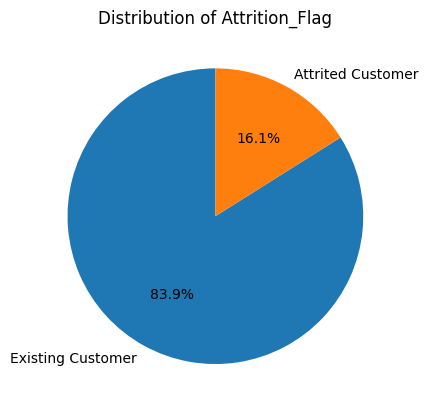

In [9]:
class_count = df['Attrition_Flag'].value_counts()
print(class_count)
plt.pie(class_count, labels=class_count.index , autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Attrition_Flag')
plt.show()

### آیا  عدم تعادل برچسب در عملکرد مدل نهایی تأثیر دارد یا خیر؟

جواب در گزارش کار آورده شده

###  چه راهکارهایی برای اصلاح این مشکل وجود دارد؟ تحقیق کنید.

جواب در گزارش کار آورده شده است

### متعادل سازی داده ها را باید قبل از تقسیم بندی به تست و ترین انجام دهیم یا بعد از ان؟

جواب در گزارش کار آورده شده است

## 6.1

### آموزش داده ها بدون متعادل سازی

**`کمی سازی داده ها`**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [22]:
qualitative_features = ['Gender', 'Education_Level', 'Marital_Status', 'Card_Category','Attrition_Flag', 'Income_Category']
quantified_df = df.copy()
for feature in qualitative_features:
    le = LabelEncoder()
    quantified_df[feature] = le.fit_transform(df[feature])


X = quantified_df.drop(['Attrition_Flag'], axis=1) ##  'CLIENTNUM'
y = quantified_df['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=13 ,stratify=y, shuffle=True)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

correlations = quantified_df.corr()


Shape of X_train: (7088, 22)
Shape of X_test: (3039, 22)


**`نرمالایز کردن داده`**

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**`آموزش مدل (غیر متعادل)`**

In [29]:
model = LogisticRegression(solver="saga", max_iter=1, random_state=13)
model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1, random_state=13, solver='saga')

**`صحت سنجی (غیر متعادل)`**

In [36]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

y_pred = model.predict(X_test_scaled)
accuracy = model.score(X_test_scaled,y_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")



report = classification_report(y_test, y_pred)
print(report)

model_weights = model.coef_
print("model_weights: ", model_weights)

# scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy');
# print("Cross-validation scores:", scores)
# print("Average accuracy:", scores.mean())

## عجیبه واقعا!! ولی خب مشکلو هم نیافتم :/


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
AUC: 1.0
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       488
           1       1.00      1.00      1.00      2551

    accuracy                           1.00      3039
   macro avg       1.00      1.00      1.00      3039
weighted avg       1.00      1.00      1.00      3039

model_weights:  [[ 0.03748137 -0.02300605  0.03603414 -0.00336107 -0.0176791   0.02920061
  -0.06106289 -0.02683395  0.06863211  0.17524848 -0.14229949 -0.18971392
   0.05088268  0.19428355  0.03340817  0.04789546 -0.12139151  0.25812966
   0.25406941  0.1005338  -2.27385804  2.27385993]]


**`رسم ماتریس درهم ریختگی (غیر متعادل)`**

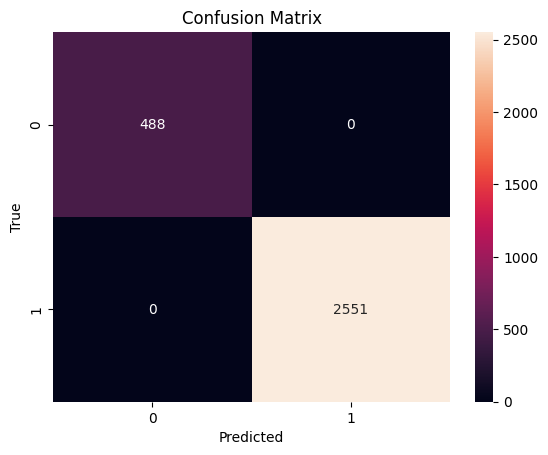

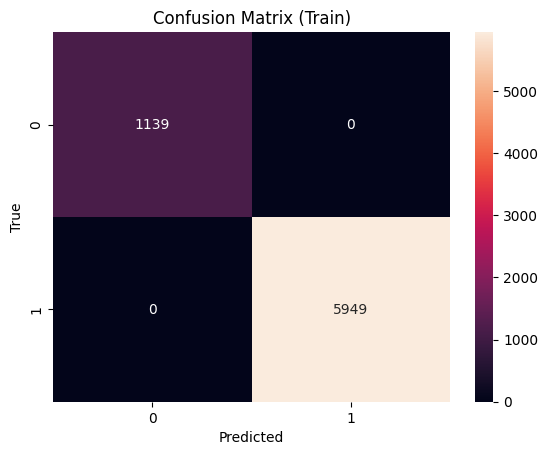

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
cm_test = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm_test, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix(Test)")
plt.show()

cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure()
sns.heatmap(cm_train, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Train)")
plt.show()


**`گزارش طبقه بندی (غیر متعادل)`**

In [37]:
from sklearn.metrics import classification_report

y_train_pred = model.predict(X_train_scaled)

print("Classification Report (train):\n", classification_report(y_train, y_train_pred))

y_test_pred = model.predict(X_test_scaled)
print("Classification Report (test):\n", classification_report(y_test, y_test_pred))


Classification Report (train):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1139
           1       1.00      1.00      1.00      5949

    accuracy                           1.00      7088
   macro avg       1.00      1.00      1.00      7088
weighted avg       1.00      1.00      1.00      7088

Classification Report (test):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       488
           1       1.00      1.00      1.00      2551

    accuracy                           1.00      3039
   macro avg       1.00      1.00      1.00      3039
weighted avg       1.00      1.00      1.00      3039



### آموزش داده ها با متعادل سازی

**`آموزش مدل (متعادل شده)`**

Shape of X_train_balanced: (11898, 22)


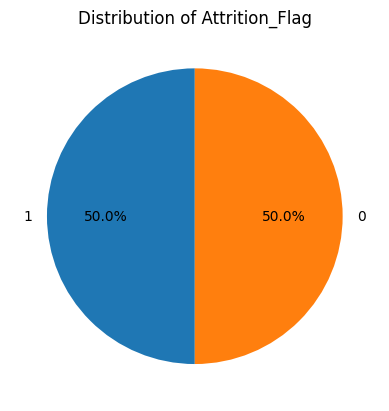

In [39]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=13)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
model = LogisticRegression()
model.fit(X_train_balanced, y_train_balanced)

print("Shape of X_train_balanced:", X_train_balanced.shape)
class_count = pd.Series(y_train_balanced).value_counts()
plt.pie(class_count, labels=class_count.index , autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Attrition_Flag')
plt.show()

**`رسم ماتریس درهم ریختگی (متعادل شده)`**

Accuracy: 1.0


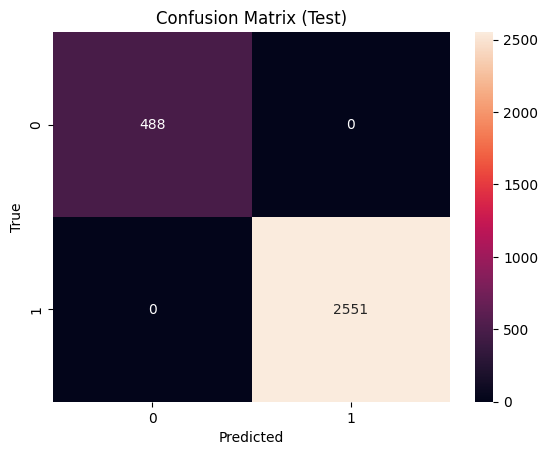

Accuracy: 1.0


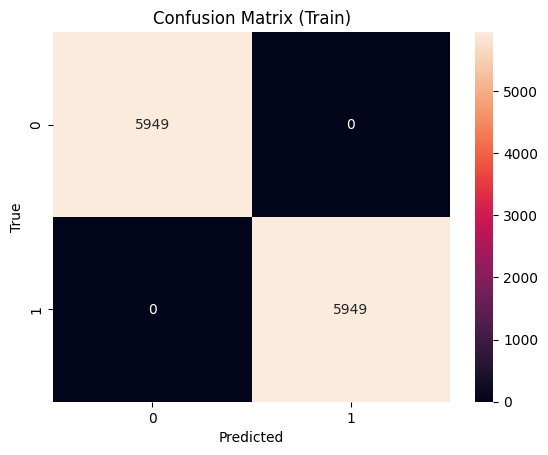

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [42]:
y_test_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy (Test): {accuracy}")
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt="d")
plt.figure(1)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test)")
plt.show()

y_train_pred = model.predict(X_train_balanced)
accuracy = accuracy_score(y_train_balanced, y_train_pred)
print(f"Accuracy (Train): {accuracy}")
cm = confusion_matrix(y_train_balanced, y_train_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.figure(1)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Train)")
plt.show()
plt.figure(2)



**`گزارش طقبه بندی (متعادل شده)`**

In [45]:
y_train_pred = model.predict(X_train_balanced)
print("Classification Report (train (balanced)):\n", classification_report(y_train_balanced, y_train_pred))

y_test_pred = model.predict(X_test_scaled)
print("Classification Report (test (balanced)):\n", classification_report(y_test, y_test_pred))

Classification Report (train (balanced)):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5949
           1       1.00      1.00      1.00      5949

    accuracy                           1.00     11898
   macro avg       1.00      1.00      1.00     11898
weighted avg       1.00      1.00      1.00     11898

Classification Report (test (balanced)):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       488
           1       1.00      1.00      1.00      2551

    accuracy                           1.00      3039
   macro avg       1.00      1.00      1.00      3039
weighted avg       1.00      1.00      1.00      3039



# سوال دوم

آپلود و رسم داده ها

In [47]:
!gdown 11DephTJrns-7CJ1sPNIOXZZhpP4H2s9h

Downloading...
From: https://drive.google.com/uc?id=11DephTJrns-7CJ1sPNIOXZZhpP4H2s9h
To: /content/data.npy
100% 928/928 [00:00<00:00, 2.51MB/s]


Text(0.5, 1.0, 'Data Distrbution')

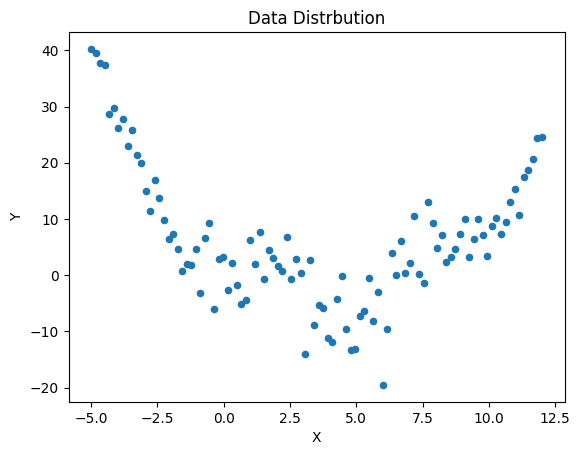

In [48]:
import numpy as np
import matplotlib.pyplot as plt
y = np.load('data.npy')
X = np.linspace(-5,12,100)
plt.scatter(X,y,s=20)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Distrbution')

## 1.2

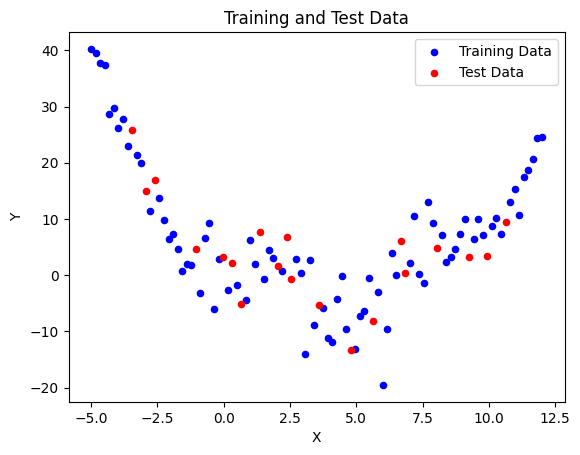

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1,1), y.reshape(-1,1)
, test_size=0.2, random_state=13)
plt.scatter(X_train, y_train, color='blue', label='Training Data',s=20)
plt.scatter(X_test, y_test, color='red', label='Test Data',s=20)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Training and Test Data')
plt.legend()
plt.show()

## 2.2

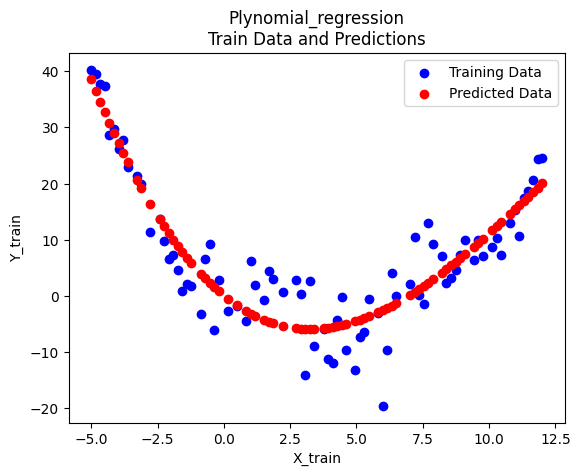

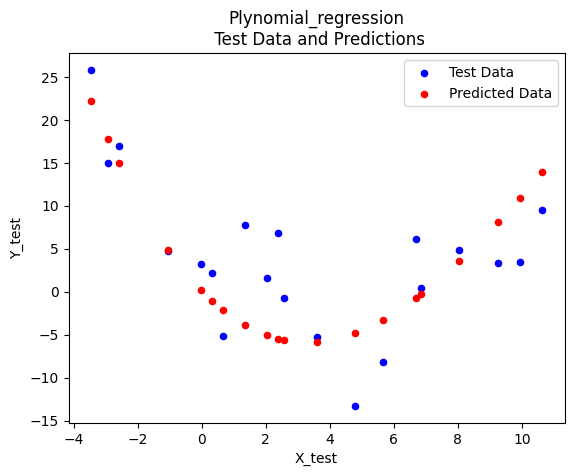

MSE: 32.717858320714
MAE: 4.646725741540726
R-squared: 0.5588323084831883


In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict on training data
y_train_pred = model.predict(X_train_poly)

plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_train, y_train_pred, color='red', label='Predicted Data')
plt.xlabel('X_train')
plt.ylabel('Y_train')
plt.title('Plynomial_regression\nTrain Data and Predictions')
plt.legend()
plt.show()

# Predict on test data
y_test_pred = model.predict(X_test_poly)

plt.scatter(X_test, y_test, color='blue', label='Test Data', s=20)
plt.scatter(X_test, y_test_pred, color='red', label='Predicted Data', s=20)
plt.xlabel('X_test')
plt.ylabel('Y_test')
plt.title('Plynomial_regression\n Test Data and Predictions')
plt.legend()
plt.show()


mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R-squared:", r2)

## 3.2

**`تعریف توابع : First-degree linear regression`**

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13, shuffle=True)

def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]

# Hypothesis
def h_w(X, w):
    return X @ w

# SSE cost function
def cost_function(X, y, w):
    return np.sum((h_w(X, w) - y)**2) / len(X)

# Gradient descent
def gradient_descent(X, y, w, alpha, num_iters):
    m = len(y)
    cost_history = []
    w_history = [w.copy()]
    X = np.c_[np.ones(X.shape[0]), X]
    # print(X.shape, y.shape)
    # print(len(w))
    # print('x = ', X)
    # print("w = ", w)

    for i in range(num_iters):
        errors = h_w(X,w) - y
        gradient = (X.T @ errors) / m
        w = w - alpha * gradient

        cost_history.append(cost_function(X, y, w))
        w_history.append(w.copy())
    return w, cost_history, w_history

**`استفاده از مدل رگرسیون خطی`**

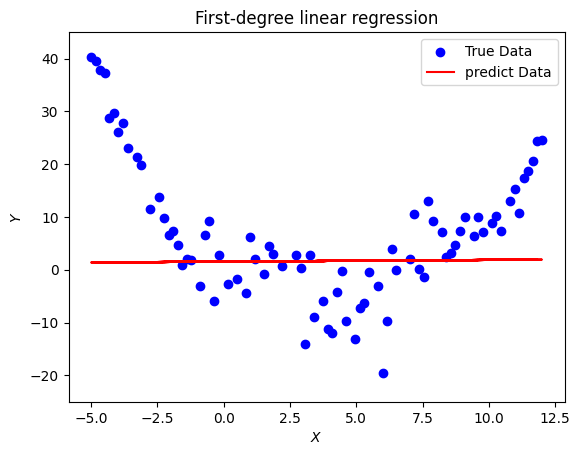

In [90]:
w_initial = np.array([1, 5])
eta = 0.02  # Learning rate
num_iters = 10

# Run Gradient Descent
w_final, cost_history, w_history = gradient_descent(X, y, w_initial, eta, num_iters)
y_train_pred = h_w(add_bias(X_train), w_final)
y_test_pred = h_w(add_bias(X_test), w_final)
plt.ylim(-25,45)
plt.xlabel("$X$")
plt.ylabel("$Y$")
plt.title("First-degree linear regression")
plt.scatter(X_train, y_train, color='blue', label='True Data')
plt.plot(X_train, y_train_pred, color='red', label='predict Data')
plt.legend()

## 4.2

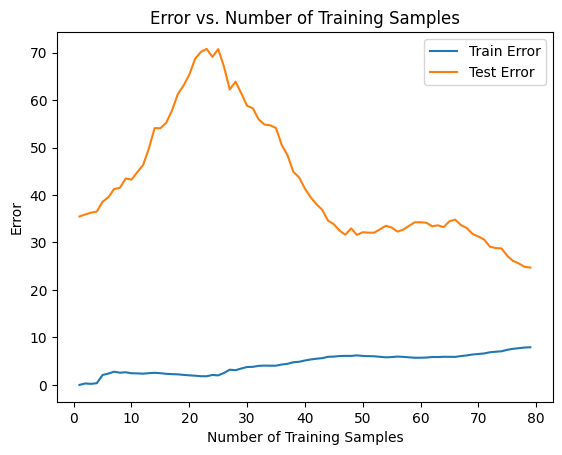

In [93]:
train_errors = []
test_errors = []
n_samples = X_train.shape[0]

#set initial paramters
w_initial = np.array([0, 1])
eta = 0.02
num_iters = 1000

for i in range(1, n_samples):
    # اختصاص عنصر اول تا آی ام به آموزش
    X_train_subset = X[:i]
    y_train_subset = y[:i]
    # اختصاص عنصر آی ام تا آی آخر به  تست
    X_test_subset = X[i:]
    y_test_subset = y[i:]


    # Run Gradient Descent
    w_final, cost_history, w_history = gradient_descent(X_train_subset, y_train_subset, w_initial, eta, num_iters)
    y_train_pred = h_w(add_bias(X_train_subset), w_final)
    y_test_pred = h_w(add_bias(X_test_subset), w_final)


    # calculate Error
    train_error = mean_absolute_error(y_train_subset, y_train_pred)
    test_error = mean_absolute_error(y_test_subset, y_test_pred)

    # Error history append
    train_errors.append(train_error)
    test_errors.append(test_error)
    # if(i<3):
    #   print('y_train', y_train_subset)
    #   print('y_train_pred', y_train_pred)
    #   print('y_test', y_test_subset)
    #   print('y_test_pred', y_test_pred)
    #   print('w_final', w_final)
    #   print('MAE_train' , train_error)
    #   print('MAE_test' , test_error)

# plotting
plt.plot(range(1, n_samples), train_errors, label='Train Error')
plt.plot(range(1, n_samples), test_errors, label='Test Error')
plt.xlabel('Number of Training Samples')
plt.ylabel('Error')
plt.title('Error vs. Number of Training Samples')
plt.legend()
plt.show()

## 5.2

درون گزارش کار آورده شده

## 6.2

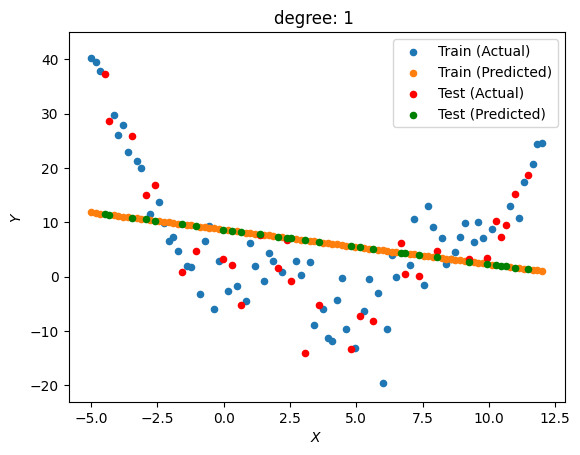

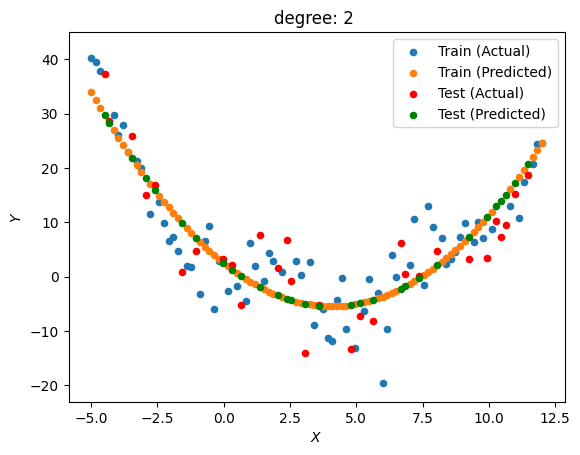

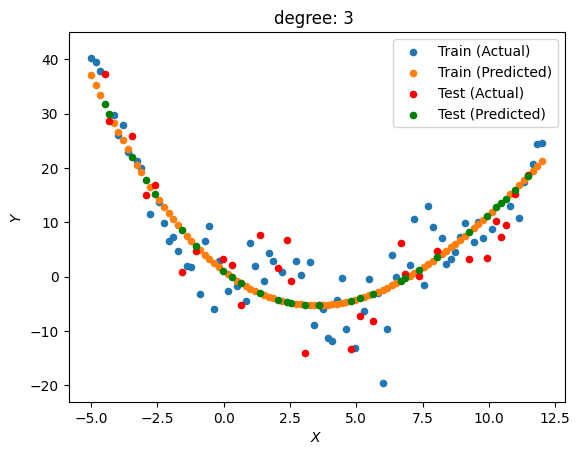

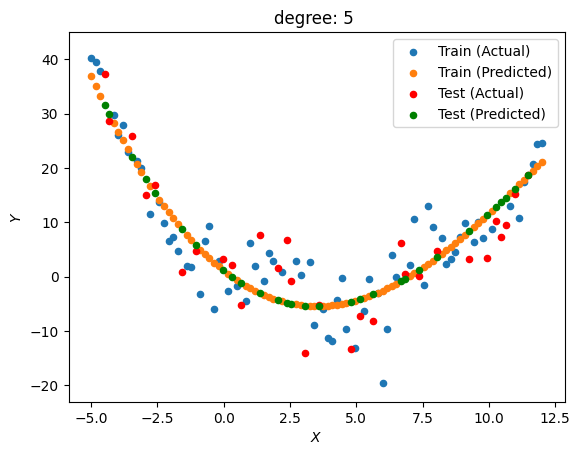

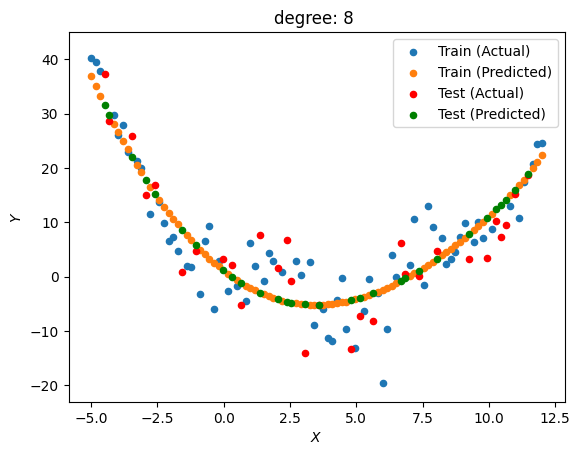

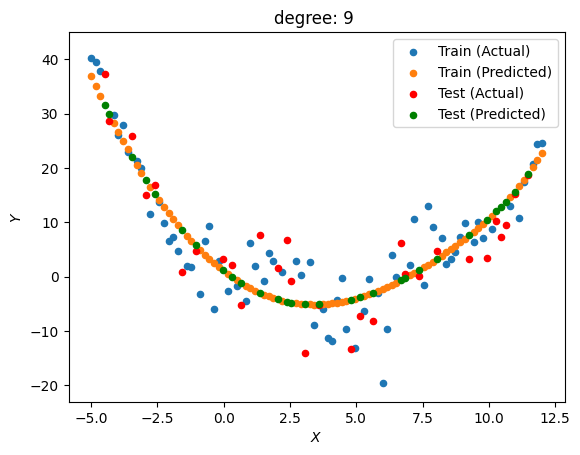

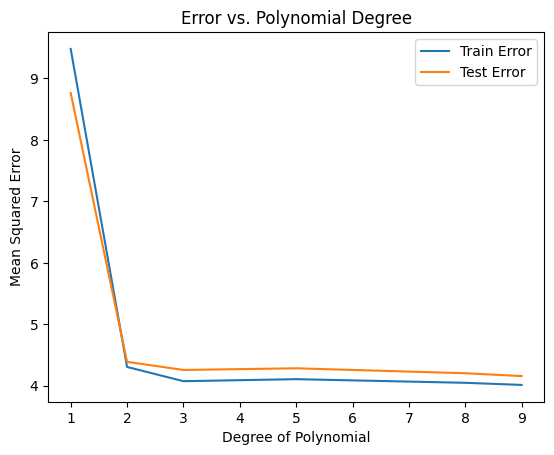

In [135]:
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=13)
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

degrees = [1,2,3,5,8,9 ]
train_errors = []
test_errors = []

 ## این دو خط را می‌توان ببریم دااخل حلقه و مدل هایی فقط با درجه ی ان داشته باشیم
X_train_poly = X_train.copy()
X_test_poly = X_test.copy()

for degree in degrees:

    # poly = PolynomialFeatures(degree=degree)
    # X_train_poly = poly.fit_transform(X_train)
    # X_test_poly = poly.fit_transform(X_test)

    #add **degree column
    X_train_poly = np.c_[X_train_poly, X_train**degree]
    X_test_poly = np.c_[X_test_poly, X_test**degree]

    #normalization
    scaler = StandardScaler()
    X_train_poly = scaler.fit_transform(X_train_poly) # fit and transorm
    X_test_poly = scaler.transform(X_test_poly)

    # training
    w_poly, cost_history, w_history = gradient_descent(X_train_poly, y_train, np.zeros(X_train_poly.shape[1]+1), 0.05, 2000)
    y_train_pred = h_w(add_bias(X_train_poly), w_poly)
    y_test_pred = h_w(add_bias(X_test_poly), w_poly)

    #plot
    plt.figure()
    plt.title(f'degree: {degree} ')
    plt.ylim(-23,45)
    plt.xlabel("$X$")
    plt.ylabel("$Y$")
    plt.scatter(X_train, y_train, s=20, label="Train (Actual)") # Train (Actual) label
    plt.scatter(X_train, y_train_pred, s=20,  label="Train (Predicted)")  # Train (Predicted) label
    plt.scatter(X_test, y_test, s=20, c='red', label="Test (Actual)")  # Test (Actual) with red color
    plt.scatter(X_test, y_test_pred, s=20,  c='green', label="Test (Predicted)") # Test (Predicted) with green color
    plt.legend()
    plt.show()


    # append mse
    train_errors.append(mean_absolute_error(y_train, y_train_pred))
    test_errors.append(mean_absolute_error(y_test, y_test_pred))

# plotting
plt.figure()
plt.plot(degrees, train_errors, label='Train Error')
plt.plot(degrees, test_errors, label='Test Error')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error')
plt.title('Error vs. Polynomial Degree')
plt.legend()
plt.show()

## 2.7

به سه روش مختلف مدل آموزش دهید

Linear Regression:
  MAE: 8.7627
  MSE: 120.7547
  R-squared: 0.0864
--------------------


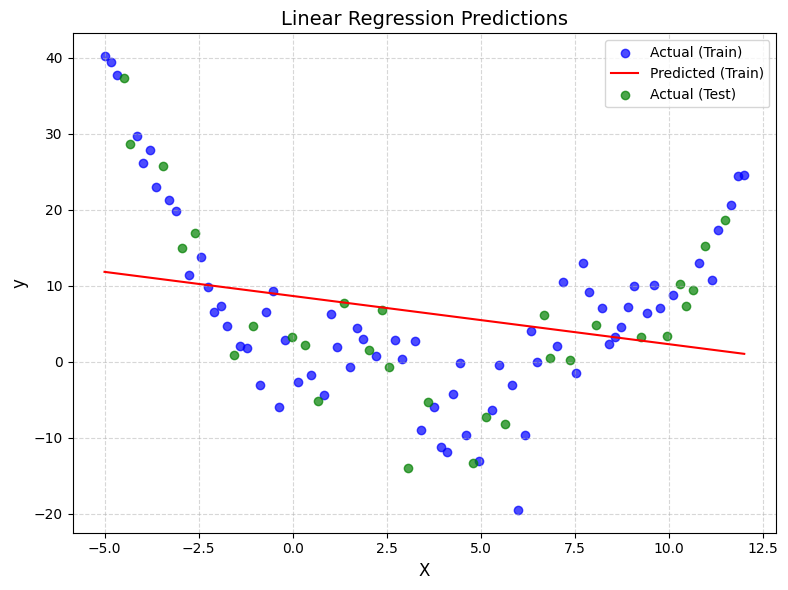

Decision Tree Regression:
  MAE: 4.0967
  MSE: 25.6470
  R-squared: 0.8060
--------------------


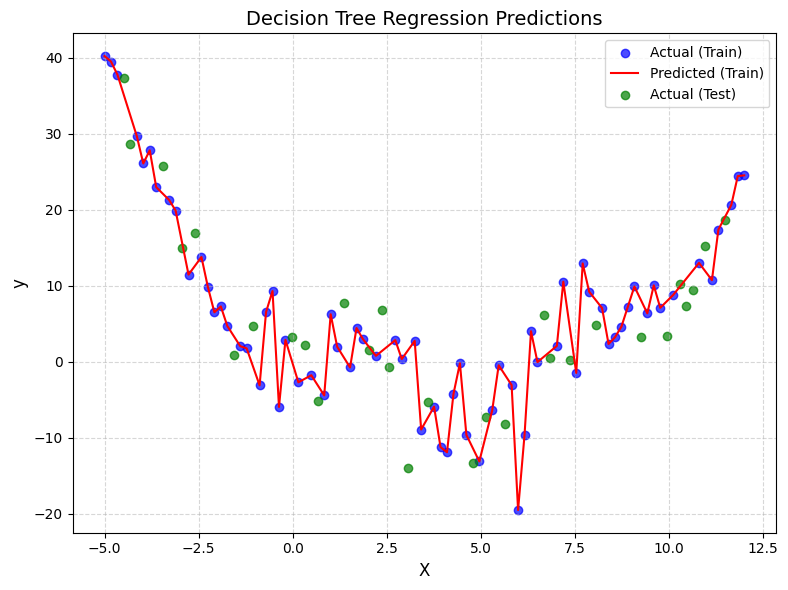

Random Forest Regression:
  MAE: 3.7834
  MSE: 21.1330
  R-squared: 0.8401
--------------------


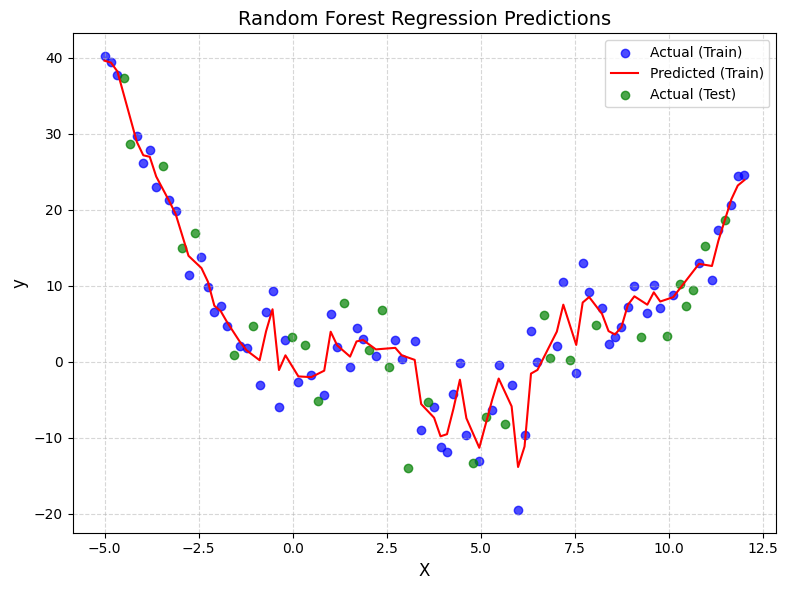

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ... (Your existing code for gradient_descent, h_w, add_bias, etc.) ...

X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1,1), y, test_size=0.3, random_state=13)

# Define the models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DecisionTreeRegressor(random_state=13),
    "Random Forest Regression": RandomForestRegressor(random_state=13)
}

# Train and evaluate each model
for model_name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred_train = model.predict(X_train)  # Predictions for training data
    y_pred_test = model.predict(X_test)  # Predictions for test data

    # Calculate errors
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)

    print(f"{model_name}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  R-squared: {r2:.4f}")
    print("-" * 20)  # Separator


    # Plot predictions vs. actual values
    plt.figure(figsize=(8, 6))  # Adjust figure size
    plt.scatter(X_train, y_train, color="blue", label="Actual (Train)", alpha=0.7)
    sorted_indices = np.argsort(X_train[:, 0])
    plt.plot(X_train[sorted_indices], y_pred_train[sorted_indices], color="red", label="Predicted (Train)")
    plt.scatter(X_test, y_test, color="green", label="Actual (Test)", alpha=0.7)
    plt.xlabel("X", fontsize=12)  # Adjust font size
    plt.ylabel("y", fontsize=12)
    plt.title(f"{model_name} Predictions", fontsize=14)  # Adjust font size
    plt.legend(fontsize=10)  # Adjust font size
    plt.grid(True, linestyle='--', alpha=0.5)  # Add grid
    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

## regulariztion

[1.53472142 0.03191776]


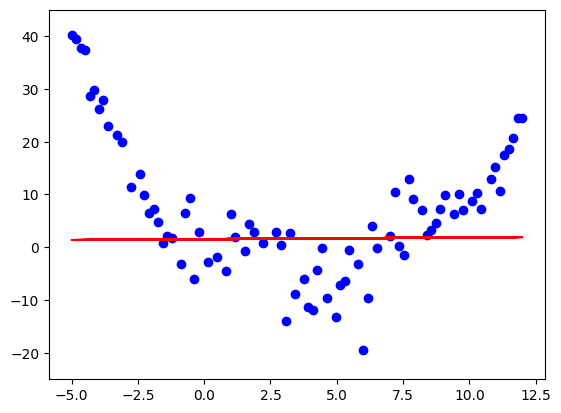

In [ ]:
from sre_constants import error
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)

def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]


def h_w(X, w):
    return X @ w

# SSE cost function
def cost_function(X, y, w, lambda_reg):
    errors =  h_w(X, w) - y
    reg_term = (lambda_reg / (2 * len(X))) * np.sum(w[1:]**2)
    cost = (errors.T @ errors) / (2 * len(X)) + reg_term
    return cost

# Gradient descent
def gradient_descent(X, y, w, alpha, num_iters, lambda_reg):

    m = len(y)
    cost_history = []
    w_history = [w.copy()]
    X = np.c_[np.ones(X.shape[0]), X]


    for i in range(num_iters):
        errors = h_w(X,w) - y
        # محاسبه گرادیان
        gradient = (X.T @ errors) / m
        gradient[1:] += (lambda_reg / m) * w[1:]
        w = w - alpha * gradient

        cost_history.append(cost_function(X, y, w, lambda_reg))
        w_history.append(w.copy())  # Store a copy of w, not the reference
    print(w)
    return w, cost_history, w_history

w_initial = np.array([1, 5])
eta = 0.02  # Learning rate
num_iters = 10
lambda_reg = 1

# Run Gradient Descent
w_final, cost_history, w_history = gradient_descent(X, y, w_initial, eta, num_iters, lambda_reg)
Z_train= np.c_[np.ones(X_train.shape[0]), X_train]
Z_test= np.c_[np.ones(X_test.shape[0]), X_test]
y_train_pred = h_w(add_bias(X_train), w_final)
y_test_pred = h_w(add_bias(X_test), w_final)
plt.ylim(-25,45)

plt.scatter(X_train, y_train, color='blue', label='True Data')
plt.plot(X_train, y_train_pred, color='red', label='predict Data')

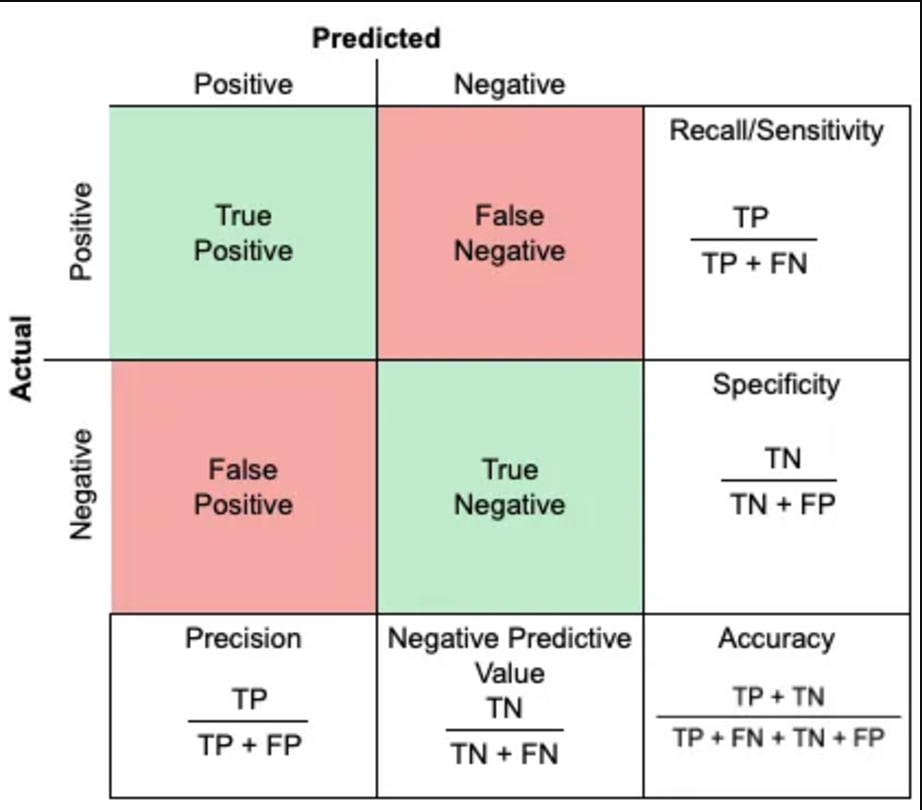